# Dynex SDK - nBit Adder Native Gate Circuit Example

First we import the required packages:

In [1]:
from pennylane import numpy as np
import pennylane as qml
from dynex import DynexConfig, ComputeBackend, DynexCircuit

config = DynexConfig(compute_backend=ComputeBackend.QPU, qpu_model="apollo_rc1", use_notebook_output=True)

We define our circuit:

In [2]:
params = [1024, 5429]  # two numbers to add, 13 qubits in this example


def Nqubits(a, b):
    mxVal = a + b
    return mxVal.bit_length()


wires = Nqubits(*params)


def Kfourier(k, wires):
    for j in range(len(wires)):
        qml.RZ(k * np.pi / (2 ** j), wires=wires[j])


def FullAdder(params, state=True):
    a, b = params
    wires = Nqubits(a, b)
    qml.BasisEmbedding(a, wires=range(wires))
    qml.QFT(wires=range(wires))
    Kfourier(b, range(wires))
    qml.adjoint(qml.QFT)(wires=range(wires))
    if state:
        return qml.state()
    else:
        return qml.sample()

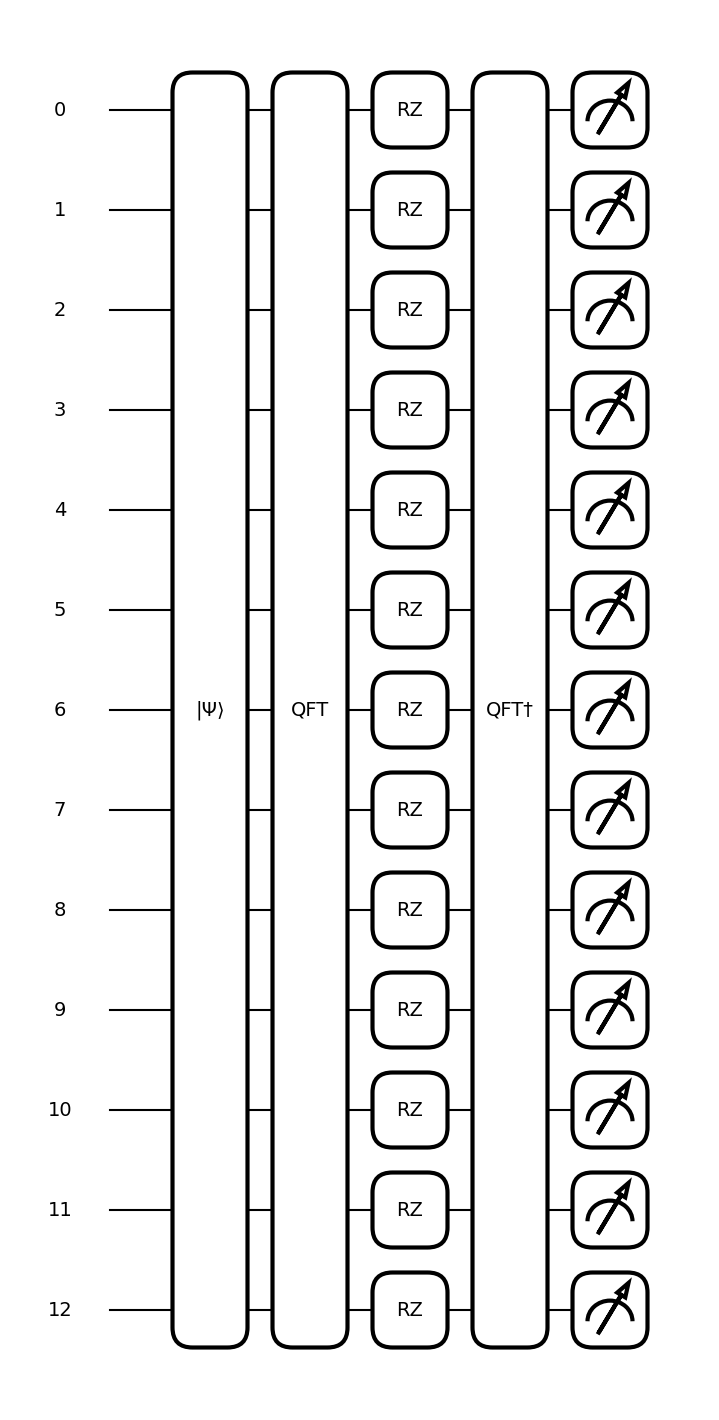

In [3]:
# draw circuit:
_ = qml.draw_mpl(FullAdder, style="black_white")(params)

We execute and measure the circuit on the Dynex platform:

In [4]:
# Execute the circuit on Dynex:
dynex_circuit = DynexCircuit(config=config)
measure = dynex_circuit.execute(FullAdder, params, wires, method="measure",
                                num_reads=10, integration_steps=100, shots=1)
print("Mesaure:", measure)

INFO: [DYNEX-APOLLO-RC1] Executing PennyLane quantum circuit
INFO: [DYNEX-APOLLO-RC1] Sampler initialised
INFO: [DYNEX-APOLLO-RC1] Apollo QPU chip: apollo_rc1
INFO: [DYNEX-APOLLO-RC1] Settings: num_reads=10, shots=1, annealing_time=100
INFO: [DYNEX-APOLLO-RC1] Submitting the job to Dynex.
INFO: [DYNEX-APOLLO-RC1] SUCCESS: Job created successfully (job_id=7410)
INFO: [DYNEX-APOLLO-RC1] feed_dict: {'cos_rz_0': 1.1264618808404609e-12, 'cos_rz_1': -0.7071067811869458, 'cos_rz_10': -0.456448982396883, 'cos_rz_11': -0.5213209268785961, 'cos_rz_12': -0.48922340148515175, 'cos_rz_2': -0.3826834323648296, 'cos_rz_3': -0.5555702330197193, 'cos_rz_4': 0.4713967368259356, 'cos_rz_5': -0.857728610000254, 'cos_rz_6': 0.26671275747491535, 'cos_rz_7': -0.7958369046088889, 'cos_rz_8': -0.31950203081601153, 'cos_rz_9': -0.5833086529377001, 'sin_rz_0': 1, 'sin_rz_1': -0.7071067811861492, 'sin_rz_10': 0.8897495863830733, 'sin_rz_11': -0.8533607040392951, 'sin_rz_12': 0.8721585082078246, 'sin_rz_2': 0.9238

Mesaure: [1 1 0 0 1 0 0 1 1 0 1 0 1]


In [5]:
bitStr = "".join(map(str, measure.astype(int)))
dynexResult = int(bitStr, 2)
print("Dynex Result:", dynexResult)
print("Expected Result:", sum(params))
isValidDynex = dynexResult == sum(params)
print("Is Dynex Result Valid?", isValidDynex)

Dynex Result: 6453
Expected Result: 6453
Is Dynex Result Valid? True
